In [33]:
# ============================================================
# BLOQUE 1: Fundamentos básicos de Electrónica de Potencia.
# Tema 2: Principios básicos y fundamentos matemáticos
#
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
#   0. Concepto de ortogonalidad
#   1. Visualizar señales periódicas
#   2. Construir una señal mediante armónicos
#   3. Estudiar una onda cuadrada
#   4. Observar el fenómeno de Gibbs
#   5. Estudiar simetría par, impar y de media onda
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# **Viñeta introducción a la ortogonalidad**
![Figura 1. Ortogonalidad y serie de Fourier](figures/3_ortogonalidad_SF.jpeg)

# **Concepto de ortogonalidad**

Dos funciones $f(t)$ y $g(t)$ son **ortogonales** sobre un intervalo de duración $T$ si el producto de ambas, integrado durante ese intervalo, es igual a cero:

$$
\boxed{
\int_{t_0}^{t_0+T} f(t)\,g(t)\,dt=0
}
$$

En las series de Fourier, las funciones seno y coseno de diferentes frecuencias armónicas presentan esta propiedad. Por ejemplo, si $\omega_0=\frac{2\pi}{T},$ entonces, para dos enteros positivos $m$ y $n$ diferentes:

$$
\boxed{
\int_{t_0}^{t_0+T}
\sin(m\omega_0t)\sin(n\omega_0t)\,dt=0,
}
\qquad
\boxed{
\int_{t_0}^{t_0+T}
\cos(m\omega_0t)\cos(n\omega_0t)\,dt=0,
}
\qquad m\neq n.
$$

Además, cualquier término seno es ortogonal a cualquier término coseno:

$$
\int_{t_0}^{t_0+T}
\sin(m\omega_0t)\cos(n\omega_0t)\,dt=0.
$$

Sin embargo, cuando se multiplica una función por ella misma, la integral ya no es cero:

$$
\boxed{
\int_{t_0}^{t_0+T}
\sin^2(n\omega_0t)\,dt
=
\frac{T}{2},
}
\qquad
\boxed{
\int_{t_0}^{t_0+T}
\cos^2(n\omega_0t)\,dt
=
\frac{T}{2}.
}
$$

> Esta propiedad permite considerar las funciones $1, \cos(\omega_0t), \sin(\omega_0t), \cos(2\omega_0t), \sin(2\omega_0t),\ldots$ como componentes independientes entre sí. La **Serie de Fourier** aprovecha precisamente esta propiedad: al multiplicar una señal periódica por un seno o coseno determinado e integrar durante un período, es posible determinar cuánto de ese componente armónico está presente en la señal.

# **Representación de señales periódicas mediante Serie de Fourier**
Una **señal periódica** puede representarse como una suma de señales sinusoidales cuyas frecuencias son múltiplos enteros de la frecuencia fundamental. Si $x(t)$ es una señal periódica de período $T$, su frecuencia angular fundamental es $ \omega_0 = \frac{2\pi}{T}.$ La serie de Fourier en forma trigonométrica puede escribirse como

$$
x(t) =
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
\left[
a_n\cos(n\omega_0t)
+
b_n\sin(n\omega_0t)
\right].
$$

Cada término de la serie representa un componente sinusoidal de la señal:

* $n=1$: componente fundamental.
* $n=2$: segundo armónico.
* $n=3$: tercer armónico.
* $n=4$: cuarto armónico.
* $\ldots$

> La frecuencia del armónico $n$ es $f_n = n f_0,$ donde $f_0 = \frac{1}{T}.$

# **Coeficientes de la serie de Fourier**
Los coeficientes de Fourier se obtienen proyectando la señal sobre las funciones sinusoidales que forman la base de Fourier.


* El coeficiente correspondiente al término constante es
$$
a_0
=
\frac{2}{T} \int_{t_0}^{t_0+T}x(t) \quad dt
$$



* Los coeficientes de los términos coseno son

$$
a_n =
\frac{2}{T}
\int_{t_0}^{t_0+T}
x(t)\cos(n\omega_0t) \quad dt
$$

* Los coeficientes de los términos seno son

$$
b_n =
\frac{2}{T}
\int_{t_0}^{t_0+T}
x(t)\sin(n\omega_0t) \quad dt
$$

El valor medio de la señal es $\left\langle x(t) \right\rangle=\frac{a_0}{2}$. Una vez calculados $a_0$, $a_n$ y $b_n$, podemos reconstruir la señal mediante

$$
x(t)=
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
\left[
a_n\cos(n\omega_0t)
\quad + \quad
b_n\sin(n\omega_0t)
\right]
$$


In [34]:
# ============================================================
# ONDA CUADRADA BIPOLAR
# ============================================================

def square_wave(t, V=1.0, f=1.0):
    """
    Onda cuadrada bipolar:

        +V  para 0 < t < T/2
        -V  para T/2 < t < T

    La señal se extiende periódicamente.
    """

    T = 1 / f

    # Llevar el tiempo al intervalo [0,T)
    t_mod = np.mod(t, T)

    return np.where(t_mod < T/2, V, -V)

In [35]:
# PARÁMETROS DE LA SEÑAL
Vdc             = 1.0           # Amplitud
f0              = 1.0           # Frecuencia fundamental [Hz]
T               = 1 / f0        # Periodo [s]
w0              = 2 * np.pi * f0  # Frecuencia angular [rad/s]

In [36]:
print(f"Amplitud Vdc       = {Vdc}")
print(f"Frecuencia f0      = {f0} Hz")
print(f"Periodo T          = {T} s")
print(f"Frecuencia angular = {w0:.4f} rad/s")

Amplitud Vdc       = 1.0
Frecuencia f0      = 1.0 Hz
Periodo T          = 1.0 s
Frecuencia angular = 6.2832 rad/s


In [37]:
# Tiempo
t             = np.linspace(-T, T, 2000, endpoint=False)

In [38]:
# Señal cuadrada bipolar
x             = square_wave(t, Vdc, f0)

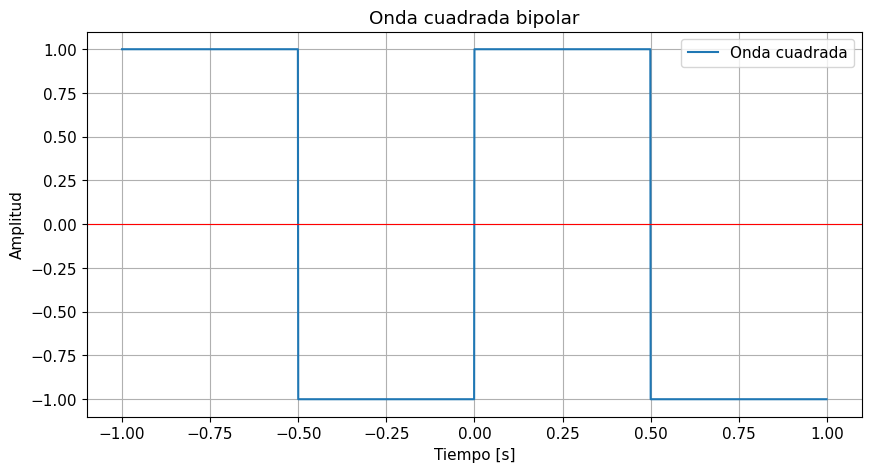

In [39]:
#plot
plt.plot(t, x, label="Onda cuadrada")
plt.axhline(0, linewidth=0.8, color='r')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Onda cuadrada bipolar")

plt.legend()
plt.show()

In [40]:
# Señal fundamental
x1            = np.sin(w0 * t)

In [41]:
# Fundamental + tercer armónico
x3            = np.sin(w0 * t)    + (1/3) * np.sin(3 * w0 * t)
# Fundamental + 3º + 5º armónico
x5            = np.sin(w0 * t)    + (1/3) * np.sin(3 * w0 * t)  + (1/5) * np.sin(5 * w0 * t)

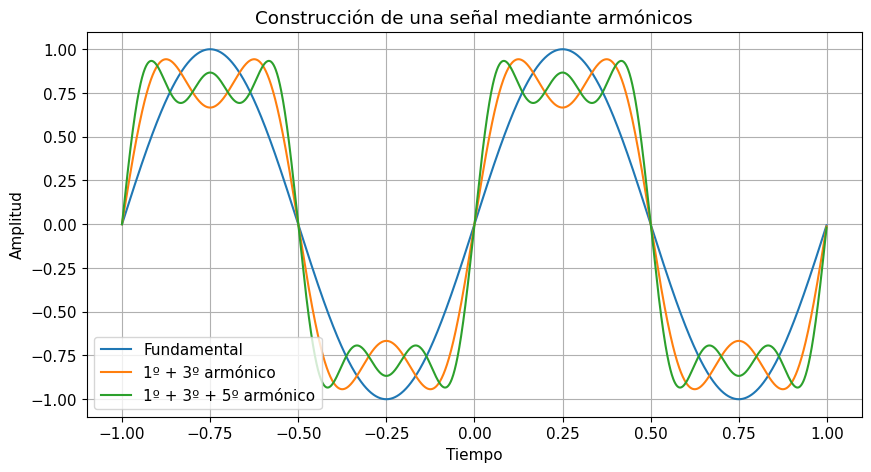

In [42]:
plt.plot(t, x1, label="Fundamental")
plt.plot(t, x3, label="1º + 3º armónico")
plt.plot(t, x5, label="1º + 3º + 5º armónico")

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Construcción de una señal mediante armónicos")
plt.grid(True)
plt.legend()
plt.show()

# **Serie de Fourier de una onda cuadrada**

Consideremos una onda cuadrada bipolar de amplitud $V_{DC}$:

$$
x(t)=
\begin{cases}
+V_{DC}, & 0<t<T/2 \\
-V_{DC}, & T/2<t<T
\end{cases}
$$

La señal presenta simetría impar, $x(-t) = -x(t)$. Su serie de Fourier contiene únicamente armónicos impares:

$$
\boxed{
x(t)=
\frac{4V_{DC}}{\pi}
\left[
\sin(\omega_0t)
\quad + \quad
\frac{1}{3}\sin(3\omega_0t)
\quad + \quad
\frac{1}{5}\sin(5\omega_0t)
\quad + \quad \cdots
\right]
}
$$

Por tanto:

$$
x(t)=
\frac{4V_{DC}}{\pi}
\sum_{\substack{n=1\\ n\ \mathrm{impar}}}^{\infty}
\frac{1}{n}
\sin(n\omega_0t).
$$

La frecuencia de cada armónico es $f_n=nf_0$. Sin embargo, los componentes armónicos presentes son únicamente los impares ($ f_0, 3f_0, 5f_0, 7f_0,\ldots$). Mientras que los armónicos pares ($2f_0, 4f_0, 6f_0,\ldots$) no aparecen.


In [43]:
# Parámetros (aunque innecesario, repetimos por didáctica)
Vdc     = 1.0       # Amplitud
f0      = 1.0        # Frecuencia fundamental [Hz]
T       = 1 / f0      # Periodo [s]
w0      = 2 * np.pi * f0  # Frecuencia angular [rad/s]

In [44]:
# Tiempo
t       = np.linspace(-T, T, 2000, endpoint=False)

In [45]:
# Número de armónicos
N_values = [1, 3, 5, 11, 51]

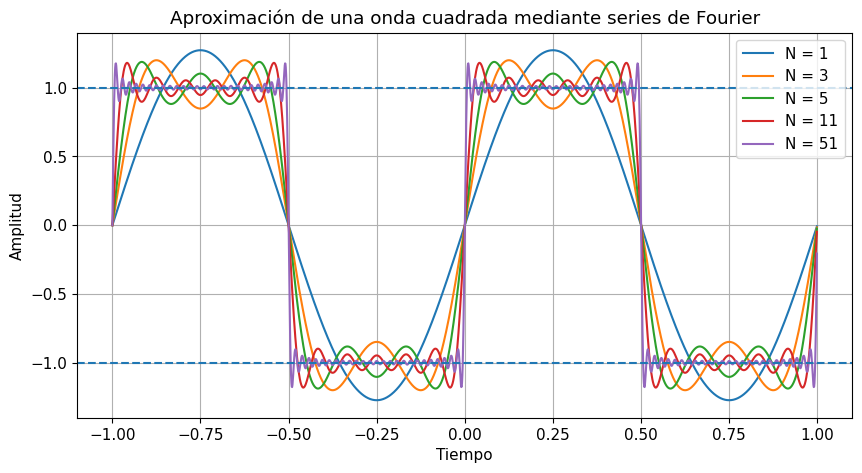

In [46]:
#
for N in N_values:
    x = np.zeros_like(t)
    for n in range(1, N + 1, 2):
        x += (4 * Vdc / np.pi) * np.sin(n * w0 * t) / n
    plt.plot(t, x, label=f"N = {N}")

plt.axhline(Vdc, linestyle="--")
plt.axhline(-Vdc, linestyle="--")

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Aproximación de una onda cuadrada mediante series de Fourier")
plt.grid(True)
plt.legend()
plt.show()

# **Espectro de la representación en serie de Fourier de la onda cuadrada**

In [47]:
# ESPECTRO TEÓRICO DE LA ONDA CUADRADA

N_max      = 15
n_values   = np.arange(1, N_max + 1)
amplitudes = np.zeros_like( n_values, dtype=float)

for i, n in enumerate(n_values):
    if n % 2 == 1:
        amplitudes[i] = 4 * Vdc / (np.pi * n)
frequencies = n_values * f0

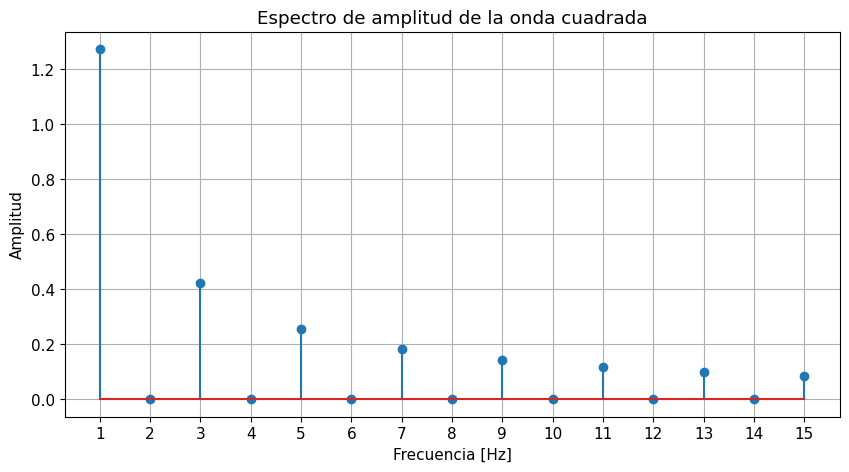

In [48]:
#Plot
plt.stem(frequencies, amplitudes)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Espectro de amplitud de la onda cuadrada")

plt.xticks(frequencies)
plt.show()

# **Fenómeno de Gibbs**
Cuando se aproxima una señal con discontinuidades mediante un número finito de términos de su serie de Fourier, aparecen oscilaciones alrededor de los puntos de discontinuidad. Este comportamiento se conoce como **fenómeno de Gibbs**.

En una onda cuadrada, las discontinuidades aparecen cuando la señal cambia de $+V_{DC}$ a $-V_{DC}$ o viceversa. Al aumentar el número de armónicos ($
N=1,3,5,11,51,\ldots $) la aproximación mejora en prácticamente todo el período. Sin embargo, cerca de las discontinuidades permanecen oscilaciones.

Una característica importante es que el exceso de amplitud asociado al fenómeno de Gibbs no desaparece completamente al aumentar $N$. Lo que ocurre es que las oscilaciones se concentran en una región cada vez más estrecha alrededor de la discontinuidad.

Por tanto:

$$
\boxed{
N\rightarrow\infty
}
$$

no implica que las oscilaciones desaparezcan localmente de la misma manera que lo hacen en las regiones suaves de la señal.


In [49]:
# Parámetros
Vdc         = 1.0       # Amplitud
f0          = 1.0        # Frecuencia fundamental [Hz]
T           = 1 / f0      # Periodo [s]
w0          = 2 * np.pi * f0  # Frecuencia angular [rad/s]

In [50]:
# Tiempo
t           = np.linspace(-T/8, T/8, 3000, endpoint=False)

In [51]:
# Número de armónicos
N           = 101

In [52]:
# Se inicializa señal con ceros
x         = np.zeros_like(t)
# Se agregan N armónicos
for n in range(1, N + 1, 2):
    x += (4 * Vdc / np.pi) * np.sin(n * w0 * t) / n

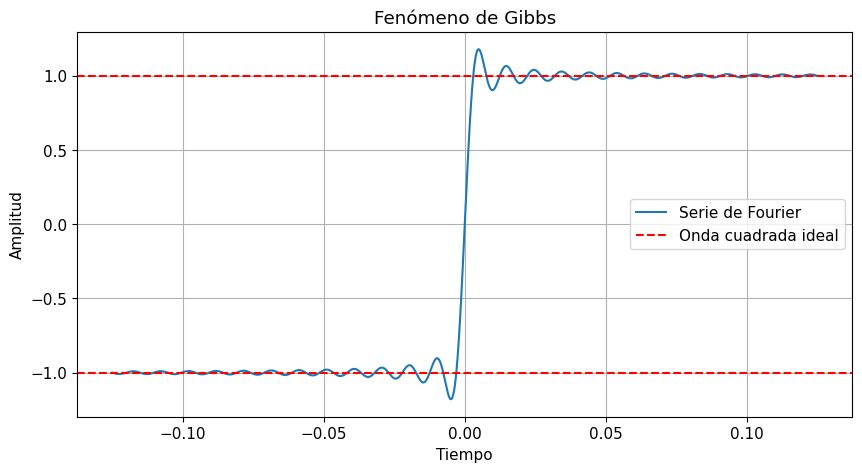

In [53]:
plt.plot(t, x, label="Serie de Fourier")
plt.axhline(Vdc, linestyle="--", label="Onda cuadrada ideal", color='r')
plt.axhline(-Vdc, linestyle="--", color='r')

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Fenómeno de Gibbs")
plt.grid(True)
plt.legend()
plt.show()

# **Simetría**

**Simetría par**. Una señal es **par** si cumple

$$
\boxed{x(t)=x(-t)}
$$

En forma grafica, una función par presenta simetría respecto al eje vertical. Matemáticamente, la represesentación en serie de Fourier

$$
x(t)=
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
\left[
a_n\cos(n\omega_0t)
+
b_n\sin(n\omega_0t)
\right]
$$

de una señal par solamente puede contener términos coseno, $b_n=0$. Por tanto, la serie se reduce a:

$$
\boxed{
x(t)=
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
a_n\cos(n\omega_0t)
}
$$

Una explicación matemática sencilla sería que $x(t)$ es par, mientras que $\sin(n\omega_0t)$ es impar. Por tanto, el producto $ x(t)\sin(n\omega_0t)$ es una función impar y su integral sobre un intervalo simétrico es cero. Una explicación formal require echar mano de la ortogonalidad.


**Simetría impar**. Una señal es **impar** si cumple

$$
\boxed{x(t)=-x(-t)}
$$

Matemáticamente, la represesentación en serie de Fourier

$$
x(t)=
\frac{a_0}{2}
+
\sum_{n=1}^{\infty}
\left[
a_n\cos(n\omega_0t)
+
b_n\sin(n\omega_0t)
\right]
$$

de una señal impar solamente puede contener términos seno, $a_0=0$ y $a_n=0$. Por tanto, la serie se reduce a:


$$
\boxed{
x(t)=
\sum_{n=1}^{\infty}
b_n\sin(n\omega_0t)
}
$$


**Simetría de media onda**. Una señal presenta **simetría de media onda** (half-way symmetry)cuando

$$
\boxed{
x(t)=-x\left(t-\frac{T}{2}\right)
}
$$

Equivalentemente, de forma grafica, la segunda mitad del período es igual a la primera mitad cambiada de signo. Esta propiedad tiene una consecuencia muy importante, dado que anula los armónicos pares ($a_{2k}=b_{2k}=0$, para cualquier entero $k$). Es decir, **los armónicos pares desaparecen**. Por tanto, una señal con **simetría de media onda** puede contener armónicos $
f_0,3f_0,5f_0,7f_0,\ldots$, pero nunca armónicos $ 2f_0, 4f_0, 6f_0,\ldots$

La **simetría de media onda** permite, por tanto, determinar la estructura espectral de una señal sin necesidad de calcular todos los coeficientes de Fourier.


# **Tabla resumen**

| Propiedad       | Condición  de Simetría| Coeficientes que desaparecen | Componentes       |
| --------------- | ---------- | ---------------------------- | ----------------- |
| **Par**         |$x(t)$    = $x(-t)$ | $b_n=0$ | DC + cosenos |
| **Impar**       |$x(t)    =-x(-t)$| $a_0=0, a_n=0$         | Senos          |
| **Media onda**  |$x(t)=-x(t-T/2)$ | $a_{2k}=b_{2k}=0$      | Armónicos impares |
| **Par + media onda**   | ambas            | $b_n=0$, armónicos pares     | cosenos impares   |
| **Impar + media onda** | ambas            | $a_0=a_n=0$, pares           | senos impares     |

# **Señal de tres niveles de amplitud**

Más adelante se estudiarán los inversores, donde a partir de una fuente de tensión continua de amplitud $V_p$ y  la conmutación de interruptores se genera una forma de onda de corriente alterna. Ahora mismo podemos observar que esta señal tiene simetría impar (no hay coeficientes $a_n$) y simietría de media onda (no hay armónicos pares, $a_{2n}=b_{2n}=0$). La representación en serie de Fourier se simplifica a:
$$
v_x(t)=
\sum_{\substack{n=1\\ n\ \mathrm{impar}}}^{\infty}
V_n \sin(n\omega_0t)
$$

La onda escalonada de tres niveles de amplitud tiene durante cada período cuatro intervalos temporales, 0, +Vp, 0 y -Vp. Denominaremos al tiempo en que permanece en cero con el parámetro $k$, si $k$ es igual a cero tendremos la forma de onda correspondiente a la onda cuadrada bipolar. El parámetro $k$ permite tener contro sobre la magnitud de los armónicos.

Cada armónico $n$ tiene una amplitud dada por:



$$
V_n
=
\frac{2}{2 \pi} \int_{\left\langle 2 \pi \right\rangle} V_x(t)\,\sin(n\omega t)\,d(\omega t)
$$

* Control de la señal fundamental $V_1 = \frac{4V_p}{\pi}\,\cos[(2\pi) k]$

* Control de armónicos.  $V_3 = \frac{4V_{p}}{3\pi}\,\cos[( 2 \pi )3k]$


La idea clave es que podemos **anular el tercer armónico** si hacemos $\cos[( 2 \pi )3k]=0$. En general, cualquier ángulo $(2\pi)k$ que haga cero el coseno eliminará el tercer armónico de la señal. Si ajustamos el ángulo de conducción $k$, podemos hacer que ese armónico sea exactamente cero.  Por tanto, el tercer armónico desaparece de la serie de Fourier. Esto permite diseñar señales con menor contenido armónico y facilita el filtrado en aplicaciones de electrónica de potencia.


In [54]:
# Parámetros de la señal
Vp          = 325       # V
f           = 50        # Hz
T           = 1 / f     # S

In [55]:
# Parámetros de la simulación
NT          = 2         # Número de periodos
N           = 2000      # Total de muestras

In [56]:

# Generación de tiempo y tensión sinusoidal
t           = np.linspace(0, NT*T, N, endpoint=False)
v_seno      = Vp * np.sin(2*np.pi*f*t)

# v_x = np.where(tau<T/4, -Vp, np.where(tau < T/2, 0, np.where(tau<3*T/4, Vp,0)))

In [57]:
# # Duración genérica del tramo de conmutación
k           = 1/8          # k=1/8,1/16,1/32
Tc          = k * T

t_mod       = t % T
t_half      = t_mod % (T/2)   # tiempo dentro de la primera mitad

# Primera mitad: empieza en 0, luego Vp durante (1/(2*k)-1)*Tc, luego 0 otra vez
v_half      = np.where(t_half < Tc,          0,
                np.where(t_half < (1/(2*k)-1)*Tc,       Vp, 0))

# Simetría impar en la segunda mitad
v_x         = np.where(t_mod < T/2, v_half, -v_half)

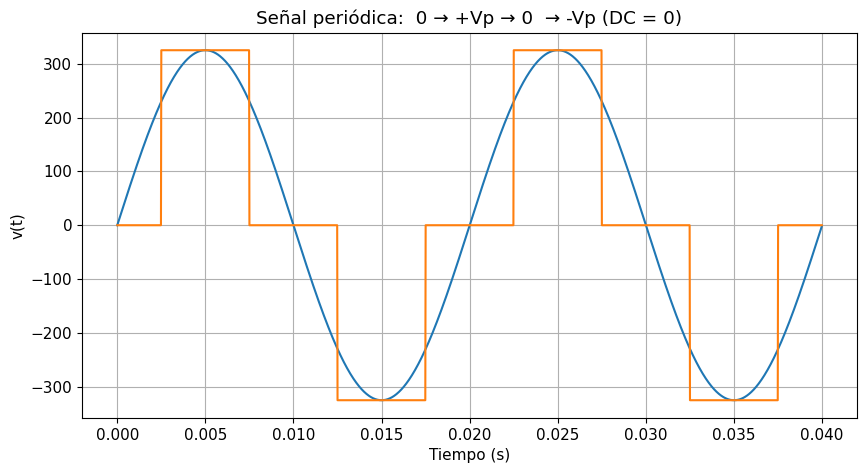

In [58]:
# Gráfica
plt.plot(t, v_seno, label="Señal senoidal")
plt.plot(t, v_x, label="Señal de tres niveles")
plt.grid(True)
plt.title("Señal periódica:  0 → +Vp → 0  → -Vp (DC = 0)")
plt.xlabel("Tiempo (s)")
plt.ylabel("v(t)")
plt.show()

# **SIMULACIÓN NGSPICE FUENTE AC SINUSOIDAL**

In [59]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ngspice is already the newest version (42+ds-3build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [60]:
# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v

******
** ngspice-42 : Circuit level simulation program
** Compiled with KLU Direct Linear Solver
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2023, The ngspice team.
** Please get your ngspice manual from https://ngspice.sourceforge.io/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Sun Mar 31 20:15:14 UTC 2024
******


In [61]:
netlist_SIN = r"""
* Generación de una señal sinusoidal
.title Señal sinusoidal
* Parámetros
.param Vp = 325
.param f0 = 50

* Fuente sinusoidal. SIN(VOFF VAMPL FREQ)
V1 out 0 SIN(0 {Vp} {f0})

* Análisis transitorio. 2 periodos de una señal de 50 Hz.
.tran 20u 40m
.control
run
* Guardar los resultados para analizarlos con Python
set wr_singlescale
wrdata sine_wave.dat v(out)
.endc
.end
"""

In [62]:
# Crear netlist
with open("sine_wave.sp", "w") as f:
    f.write(netlist_SIN)
print("Netlist creado: sine_wave.sp")

Netlist creado: sine_wave.sp


In [63]:
# Leer señal generada por ngspice
data = np.loadtxt("sine_wave.dat")

FileNotFoundError: sine_wave.dat not found.

In [ ]:
# Separar tiempo y tensión
t_ng      = data[:, 0]
v_sine_ng = data[:, 1]

In [ ]:
plt.plot(t_ng, v_sine_ng)

plt.xlabel("Tiempo [s]")
plt.ylabel("Tensión [V]")
plt.title("Señal sinusoidal generada con ngspice")

plt.grid(True)
plt.show()

# **SIMULACIÓN NGSPICE FUENTE AC SINUSOIDAL FUNDAMENTAL Y ARMÓNICOS**

In [ ]:
netlist_harmonics = r"""
* Fundamental + tercer + quinto armónico
.title Señal sinusoidal y armónicos

* Parámetros

.param Vdc = 325
.param f0  = 50
.param PI  = 3.141592653589793

* Amplitud de la componente fundamental
.param A1 = {4*Vdc/PI}

* Componentes de Fourier
* Fundamental
  V1 n1 0 SIN(0 {A1} {f0})
* Tercer armónico
  V3 n3 0 SIN(0 {A1/3} {3*f0})
* Quinto armónico
  V5 n5 0 SIN(0 {A1/5} {5*f0})
* Suma de los tres componentes
  Bsum out 0 V = V(n1) + V(n3) + V(n5)

* Análisis transitorio
.tran 10u 40m
.control
run
* Exportar los datos
set wr_singlescale
wrdata sine_harmonics.dat v(n1) v(n3) v(n5) v(out)

.endc
.end
"""

In [ ]:
# Crear netlist
with open("sine_harmonics.sp", "w") as f:
    f.write(netlist_harmonics)
print("Netlist creado: sine_harmonics.sp")

In [ ]:
# Leer señal generada por ngspice
data = np.loadtxt("sine_harmonics.dat")

In [ ]:
# Separar tiempo y armónicos
t_ng      = data[:, 0] #Tiempo
v1_ng = data[:, 1] #Fundamental
v3_ng = data[:, 2] #Tercer
v5_ng = data[:, 3] #Quinto
vsum_ng = data[:, 4] #Suma Total

In [ ]:
plt.plot(t_ng, v1_ng, label="Fundamental")
plt.plot(t_ng, v3_ng, label="3º armónico")
plt.plot(t_ng, v5_ng, label="5º armónico")

plt.xlabel("Tiempo [s]")
plt.ylabel("Tensión [V]")
plt.title("Componentes armónicos generados con ngspice")

plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.plot(t_ng, vsum_ng,  label="Fundamental + 3º + 5º armónico")
plt.xlabel("Tiempo [s]")
plt.ylabel("Tensión [V]")
plt.title("Aproximación de una onda cuadrada con ngspice")
plt.legend(loc='upper right')
plt.show()

# **Señales no periódicas: Oscilaciones de corta duración**

![Figura 1. Oscilaciones](figures/1_oscila.jpeg)


# **Representación mediante SF de señales no periódicas: Oscilaciones**

![Figura 2. Análisis en frecuencia](figures/2_oscila.jpeg)
